In [22]:
from tensorboard.backend.event_processing import event_accumulator
from config import *

In [23]:
data = []

for path in LOG_DIR.iterdir():
    ea = event_accumulator.EventAccumulator(str(path))
    ea.Reload()
    for tag in ea.Tags()["scalars"]:
        type_name, env_name = tag.split("/")
        for event in ea.Scalars(tag):
            data.append(
                {
                    "Type": type_name,
                    "env": env_name,
                    "step": event.step,
                    "value": event.value,
                    "wall_time": event.wall_time
                }
            )

In [24]:
import pandas as pd


df = pd.DataFrame(data)

In [25]:
success_ratio_df = df[(df["Type"] == "Success ratio %") & (df["env"] == "key")]

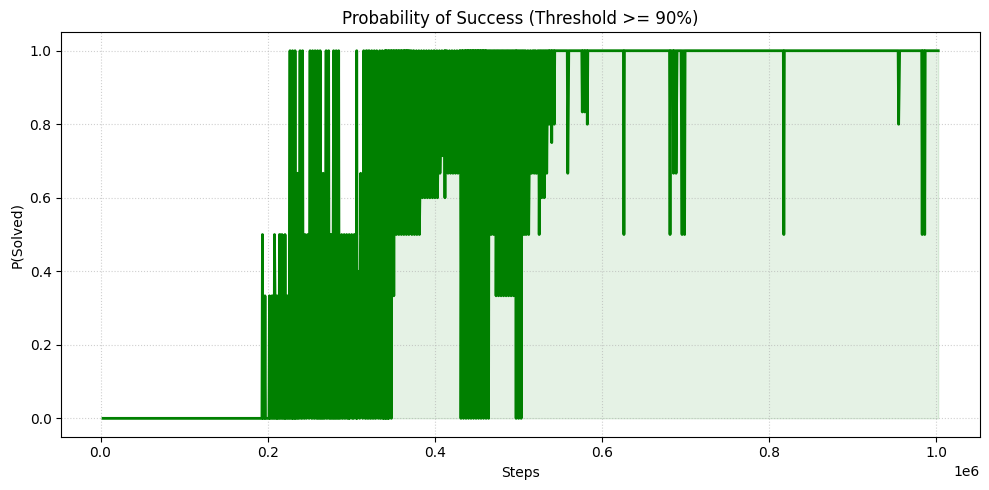

In [33]:
import matplotlib.pyplot as plt

# 1. Schwellenwert festlegen (z.B. 0.9, da deine Runs gegen 1.0 konvergieren)
threshold = 0.9

# 2. Markieren, welche Zeilen den Threshold erreicht haben (True/False)
success_ratio_df['is_solved'] = success_ratio_df['value'] >= threshold

# 3. Gruppieren nach 'step' und den Mittelwert der Booleans berechnen.
# Da True=1 und False=0 ist, ergibt der Mean genau die Wahrscheinlichkeit (0.0 bis 1.0)
prob_df = success_ratio_df.groupby('step')['is_solved'].mean().reset_index()

# 4. Plotten
plt.figure(figsize=(10, 5))
plt.plot(prob_df['step'], prob_df['is_solved'], color='green', linewidth=2)

# Optik für wissenschaftliche Berichte
plt.fill_between(prob_df['step'], prob_df['is_solved'], color='green', alpha=0.1)
plt.ylim(-0.05, 1.05) # Ein bisschen Puffer, damit man 0 und 1 gut sieht
plt.title("Probability of Success (Threshold >= 90%)")
plt.xlabel("Steps")
plt.ylabel("P(Solved)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(SAVE_PATH, format="jpg", bbox_inches="tight")
plt.show()

In [27]:
displayable = success_ratio_df.groupby("step")["value"].median().reset_index()

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Angenommen 'df' ist dein fertig verarbeiteter DataFrame
# 'Epoche' und 'Reward' sind Spaltennamen in deinem df

displayable.plot(x='step', y='value', kind='line')

# Für Papers/Wissenschaft immer gut: Ein Grid und sauberes Anzeigen
plt.grid(True)
plt.ylabel('Total Reward') # x-Label wird automatisch aus dem Spaltennamen generiert
plt.tight_layout() # Verhindert abgeschnittene Ränder
plt.show()

<Figure size 600x400 with 1 Axes>

In [31]:
from tensorboard.backend.event_processing import event_accumulator
from config import *
event_acc = event_accumulator.EventAccumulator("logs/key_c/_run_0")
event_acc.Tags()
ea = event_accumulator.EventAccumulator("/home/felix/projects/Python/Curriculum/logs/key_c/_run_5")
data = []

for path in LOG_DIR.iterdir():
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()
    for tag in ea.Tags()["scalars"]:
        type_name, env_name = tag.split("/")
        for event in ea.Scalars(tag):
            data.append(
                {
                    "Type": type_name,
                    "env": env_name,
                    "step": event.step,
                    "value": event.value,
                    "wall_time": event.wall_time
                }
            )
import pandas as pd

df = pd.DataFrame(data)
df
success_ratio_df = df[(df["Type"] == "Success ratio %") & (df["env"] == "key")]
success_ratio_df.head()
displayable = success_ratio_df.groupby("step")["value"].mean().reset_index()
import matplotlib.pyplot as plt

plt.tight_layout()

displayable.plot(x='step', y='value', kind='line')

plt.show()

TypeError: Expected binary or unicode string, got PosixPath('/home/felix/projects/Python/Curriculum/logs/key_c/_run_6')

In [ ]:
ea.helpme